# SCS 3546: Deep Learning - Convolutional Neural Nets and Transfer Learning
> Assignment 2: Convolutional Neural Nets and Transfer Learning

## Assignment Description

* Perform image classification using transfer learning with the VGG16 model pretrained on ImageNet.
* Preprocess a flower image dataset by resizing to 224×224 pixels and organizing an 80/20 stratified train-test split.
* Add custom dense layers on top of VGG16 and experiment with different architectures and hyperparameters.
* Train three models: (1) frozen base, (2) fine-tuned block 5, (3) fully fine-tuned VGG16.
* Use data augmentation, regularization, and early stopping to improve model generalization.
* Evaluate and compare all models using training, validation, and held-out test accuracy.
* Document design choices, training curves, and results to justify conclusions.




# Set up notebook with libraries

In [ ]:
import numpy as np
import tensorflow as tf
import os
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Dense
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from tensorflow.keras import Input
from tensorflow.keras.optimizers import SGD
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#from tensorflow.keras.preprocessing.image import ImageDataGenerator

import random
from PIL import Image
from tqdm import tqdm
import matplotlib.pyplot as plt

#!pip install tabulate
from tabulate import tabulate

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Dataset

We will be using the small flower dataset (http://download.tensorflow.org/example_images/flower_photos.tgzLinks).
This dataset has 5 classes (Daisy, Dandelion, Rose, Sunflower, and Tulip).
Images for each class are stored in its own folder.



## Mount Google Drive / Copy File / Extract Archive to Working Directory

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


# Copy archive from Google Drive to current working directory
!cp "/content/drive/MyDrive/Colab Notebooks/SCS_3546_Deep Learning/Assignment 2 - Convolutional Neural Nets and Transfer Learning/flower_photos.tgz" .

# Extract it
import tarfile

with tarfile.open("flower_photos.tgz", "r:gz") as tar:
    tar.extractall()
    print("Extraction complete.")

MessageError: Error: credential propagation was unsuccessful

## Verify Dataset Contents

In [ ]:
base_dir = "flower_photos"
classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

for cls in classes:
    num_images = len(os.listdir(os.path.join(base_dir, cls)))
    print(f"{cls}: {num_images} images")


roses: 641 images
sunflowers: 699 images
daisy: 633 images
dandelion: 898 images
tulips: 799 images


# Data Preprocessing

## Inspect images

ROSES - 2332478138_28f1d586e4_n.jpg: size = (320, 213), mode = RGB
SUNFLOWERS - 7012366081_019c8a17a4_m.jpg: size = (180, 240), mode = RGB
DAISY - 4222584034_8964cbd3de.jpg: size = (500, 331), mode = RGB
DANDELION - 6035460327_4bbb708eab_n.jpg: size = (320, 213), mode = RGB
TULIPS - 13529687904_3d60abb479_n.jpg: size = (320, 240), mode = RGB


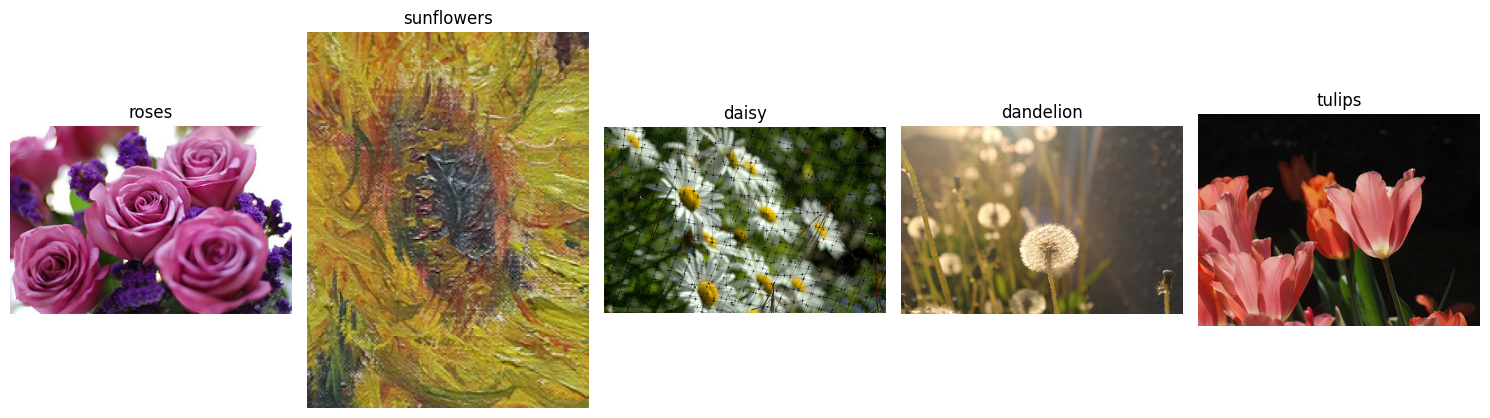

In [ ]:
base_dir = "flower_photos"
classes = [d for d in os.listdir(base_dir) if os.path.isdir(os.path.join(base_dir, d))]

plt.figure(figsize=(15, 8))

for idx, cls in enumerate(classes):
    class_path = os.path.join(base_dir, cls)
    image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, image_name)

    # Open image and print info
    image = Image.open(image_path)
    print(f"{cls.upper()} - {image_name}: size = {image.size}, mode = {image.mode}")

    # Plot
    plt.subplot(1, 5, idx + 1)
    plt.imshow(image)
    plt.title(cls)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Image sizes vary from 240x213 to 500x334
# All are in RGB mode (which is compatible with VGG16)
# Rezising is needed

## Resize images to 224x224 and normalize

In [ ]:
image_size = (224, 224)
data = []
labels = []

class_names = sorted(classes)  # ensure label consistency
label_map = {name: idx for idx, name in enumerate(class_names)}

for cls in class_names:
    class_path = os.path.join(base_dir, cls)
    for fname in tqdm(os.listdir(class_path), desc=f"Processing {cls}"):
        fpath = os.path.join(class_path, fname)
        try:
            img = Image.open(fpath).convert("RGB")              # Ensure RGB
            img = img.resize(image_size, Image.BILINEAR)        # Resize to 224x224
            img_array = np.array(img) / 255.0                   # Normalize to [0, 1]
            data.append(img_array)
            labels.append(label_map[cls])
        except Exception as e:
            print(f"Skipped file {fname}: {e}")

Processing tulips: 100%|██████████| 799/799 [00:02<00:00, 303.96it/s]


In [ ]:
# All images resized to 224×224
# All images converted to RGB mode, just in case... (required by VGG16)
# Pixel values normalized to [0, 1]
# Class labels mapped to integers (0–4)

## Split images to for training, validation and test (stratified)

In [ ]:
# Step 1: Stratified test split (20% of data)
data_train_val, data_test, labels_train_val, labels_test = train_test_split(
    data, labels, test_size=0.20, stratify=labels, random_state=42
)

# Step 2: Stratified validation split (20% of training)
data_train, data_val, labels_train, labels_val = train_test_split(
    data_train_val, labels_train_val, test_size=0.20, stratify=labels_train_val, random_state=42
)

# Step 3: Convert each split to NumPy arrays (use float16 to reduce memory)
X_train = np.array(data_train, dtype=np.float16)
y_train = np.array(labels_train)

X_val = np.array(data_val, dtype=np.float16)
y_val = np.array(labels_val)

X_test = np.array(data_test, dtype=np.float16)
y_test = np.array(labels_test)



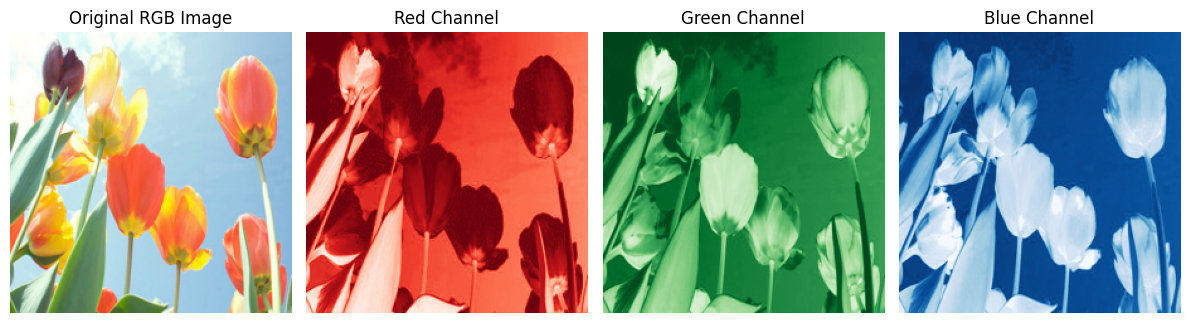

In [ ]:
#Visualizing RGB channels of one Image

# Pick a sample image
sample_image = X_train[1000].astype('float32')  # shape: (224, 224, 3)

# Split into R, G, B channels
R = sample_image[:, :, 0]
G = sample_image[:, :, 1]
B = sample_image[:, :, 2]

# Plot original image and its channels
plt.figure(figsize=(12, 4))

plt.subplot(1, 4, 1)
plt.imshow(sample_image)
plt.title("Original RGB Image")
plt.axis('off')

plt.subplot(1, 4, 2)
plt.imshow(R, cmap='Reds')
plt.title("Red Channel")
plt.axis('off')

plt.subplot(1, 4, 3)
plt.imshow(G, cmap='Greens')
plt.title("Green Channel")
plt.axis('off')

plt.subplot(1, 4, 4)
plt.imshow(B, cmap='Blues')
plt.title("Blue Channel")
plt.axis('off')

plt.tight_layout()
plt.show()

### Verify Stratification

In [ ]:
def print_class_distribution(y, split_name):
    unique, counts = np.unique(y, return_counts=True)
    total = len(y)
    print(f"\nClass distribution in {split_name}:")
    for label, count in zip(unique, counts):
        percentage = (count / total) * 100
        print(f"  Class {label}: {count} ({percentage:.2f}%)")

# Apply to all three splits
print_class_distribution(y_train, "Training set")
print_class_distribution(y_val, "Validation set")
print_class_distribution(y_test, "Test set")


Class distribution in Training set:
  Class 0: 405 (17.25%)
  Class 1: 575 (24.49%)
  Class 2: 410 (17.46%)
  Class 3: 447 (19.04%)
  Class 4: 511 (21.76%)

Class distribution in Validation set:
  Class 0: 101 (17.18%)
  Class 1: 144 (24.49%)
  Class 2: 103 (17.52%)
  Class 3: 112 (19.05%)
  Class 4: 128 (21.77%)

Class distribution in Test set:
  Class 0: 127 (17.30%)
  Class 1: 179 (24.39%)
  Class 2: 128 (17.44%)
  Class 3: 140 (19.07%)
  Class 4: 160 (21.80%)


In [ ]:
# Each split (training, validation, and test) maintains consistent class proportions, confirming that stratification worked as intended.

In [ ]:
# Verify shape of train split
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (2348, 224, 224, 3)
y_train shape: (2348,)


In [ ]:
# Dataset split into train (64%), val (16%), and test (20%) using stratified sampling
# Stratification ensures same class distribution across all subsets
# Only split subsets converted to NumPy arrays (memory-efficient)
# Image arrays stored as float16 to reduce RAM usage
# Final shape: X_train → (2348, 224, 224, 3), y_train → (2348,)

# Load pretrained VGG16 without top layers

In [ ]:
# Load the VGG16 base model
from tensorflow.keras.applications import VGG16

vgg_base = VGG16(
    weights='imagenet',          # Load pretrained weights
    include_top=False,           # Exclude the original FC classifier
    input_shape=(224, 224, 3)    # Match your resized image dimensions
)

# Confirm architecture
vgg_base.summary()

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

# Model 1 - Freezing all of VGG16 and only training fully connected layers on top

## Model 1.1 - Baseline model (No Regularization)


In [ ]:
# 1. Freeze VGG16 base layers
for layer in vgg_base.layers:
    layer.trainable = False

# 2. Add custom classification head (no dropout, no batchnormalization)
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
output = Dense(5, activation='softmax')(x)

# 3. Create model
model_1_1 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile model
model_1_1.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping callback
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 6. Train the model
history_1_1 = model_1_1.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 34s 293ms/step - accuracy: 0.2605 - loss: 1.6412 - val_accuracy: 0.4592 - val_loss: 1.4285
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 188ms/step - accuracy: 0.5194 - loss: 1.3803 - val_accuracy: 0.6020 - val_loss: 1.2517
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 222ms/step - accuracy: 0.6275 - loss: 1.2176 - val_accuracy: 0.6344 - val_loss: 1.1218
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 14s 192ms/step - accuracy: 0.6349 - loss: 1.1144 - val_accuracy: 0.6497 - val_loss: 1.0247
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 195ms/step - accuracy: 0.6823 - loss: 1.0028 - val_accuracy: 0.6752 - val_loss: 0.9557
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 201ms/step - accuracy: 0.6719 - loss: 0.9441 - val_accuracy: 0.7347 - val_loss: 0.8927
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 229ms/step - accuracy: 0.7083 - loss: 0.8883 - val_accuracy: 0.7364 - val_loss: 0.8492
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 197ms/step - accuracy: 0.7392 - loss: 0.8323 - val_accu

### Model 1.1 - Model results

In [ ]:
def summarize_model_results(history, iteration_name="Model 1 – Iteration 1 (Baseline)"):
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    train_loss = history.history['loss'][-1]
    val_loss = history.history['val_loss'][-1]

    table = [
        ["Training Accuracy", f"{train_acc:.4f}"],
        ["Validation Accuracy", f"{val_acc:.4f}"],
        ["Training Loss", f"{train_loss:.4f}"],
        ["Validation Loss", f"{val_loss:.4f}"]
    ]

    print(f"\n📌 {iteration_name}\n")
    print(tabulate(table, headers=["Metric", "Value"], tablefmt="github"))

summarize_model_results(history_1_1)


📌 Model 1 – Iteration 1 (Baseline)

| Metric              |   Value |
|---------------------|---------|
| Training Accuracy   |  0.8015 |
| Validation Accuracy |  0.8214 |
| Training Loss       |  0.5976 |
| Validation Loss     |  0.5987 |


### Model 1.1 - Learning curves

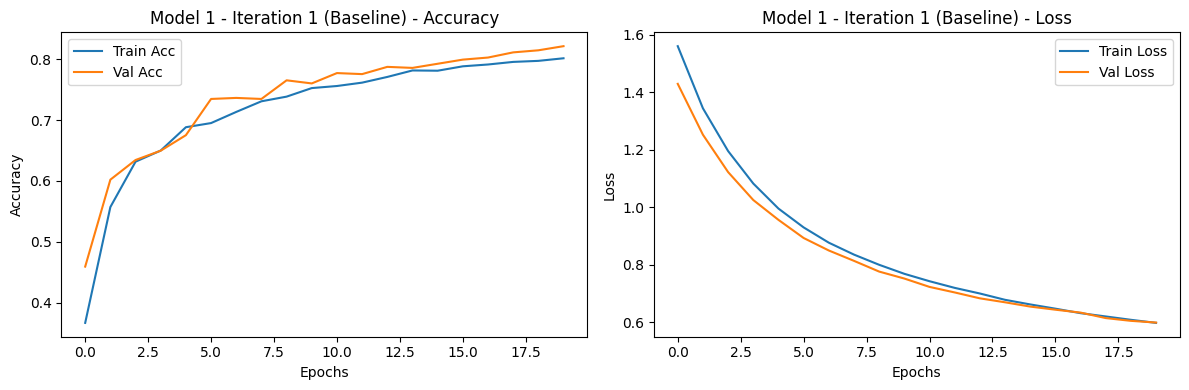

In [ ]:
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'{title} - Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'{title} - Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history_1_1, "Model 1 - Iteration 1 (Baseline)")

In [ ]:
# Custom fully connected layers: GlobalAveragePooling → Dense(256, relu) → Dense(5, softmax)
# No regularization, no batch normalization
# Optimizer: Adam, learning rate = 1e-4
# Batch size: 32
# Early stopping used (patience=3)
# Training Accuracy: 80.2%, Validation Accuracy: 82.1%, Test Accuracy: not evaluated yet
# Result: Strong baseline with excellent generalization and no signs of overfitting; next step is to introduce Dropout and BatchNormalization to observe their impact on regularization and training dynamics.

## Model 1.2 - Inroducing Dropout

In [ ]:
# 1. Freeze VGG16 base layers
for layer in vgg_base.layers:
    layer.trainable = False

# 2. Add classification head with Dropout
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)  # NEW: Dropout to reduce overfitting
output = Dense(5, activation='softmax')(x)

# 3. Create model
model_1_2 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile model
model_1_2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 6. Train the model
history_1_2 = model_1_2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 244ms/step - accuracy: 0.2324 - loss: 1.7181 - val_accuracy: 0.4898 - val_loss: 1.4381
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 35s 200ms/step - accuracy: 0.3313 - loss: 1.5312 - val_accuracy: 0.5986 - val_loss: 1.2998
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 201ms/step - accuracy: 0.4594 - loss: 1.3538 - val_accuracy: 0.6259 - val_loss: 1.1941
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 203ms/step - accuracy: 0.5341 - loss: 1.2411 - val_accuracy: 0.6922 - val_loss: 1.1084
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 232ms/step - accuracy: 0.5758 - loss: 1.1761 - val_accuracy: 0.6905 - val_loss: 1.0376
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 204ms/step - accuracy: 0.5953 - loss: 1.1065 - val_accuracy: 0.6871 - val_loss: 0.9891
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 204ms/step - accuracy: 0.6445 - loss: 1.0252 - val_accuracy: 0.7143 - val_loss: 0.9390
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 15s 207ms/step - accuracy: 0.6672 - loss: 0.9860 - val_accu

### Model 1.2 - Model results

In [ ]:
summarize_model_results(history_1_2, "Model 1 – Iteration 2 (Dropout)")


📌 Model 1 – Iteration 2 (Dropout)

| Metric              |   Value |
|---------------------|---------|
| Training Accuracy   |  0.7491 |
| Validation Accuracy |  0.7789 |
| Training Loss       |  0.727  |
| Validation Loss     |  0.6727 |


### Model 1.2 - Learning curves

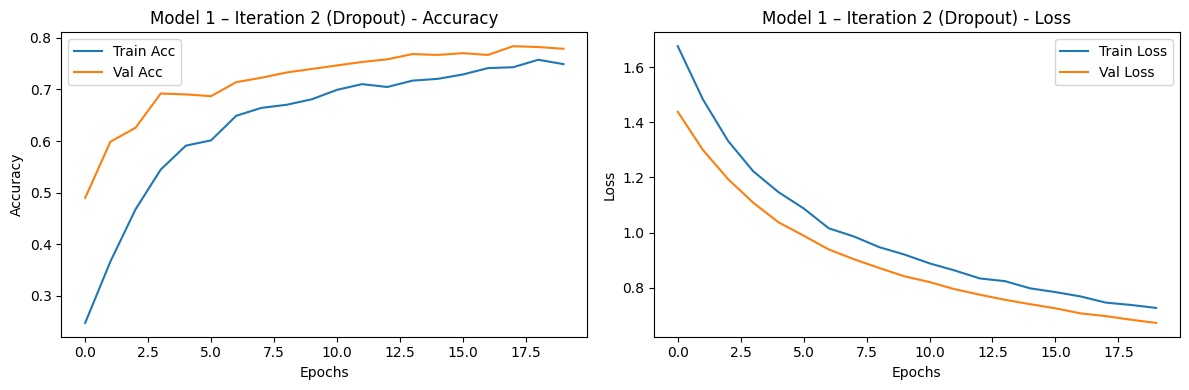

In [ ]:
plot_history(history_1_2, "Model 1 – Iteration 2 (Dropout)")

In [ ]:
# Custom head: GlobalAveragePooling → Dense(256, relu) → Dropout(0.5) → Dense(5, softmax)
# Regularization: Dropout(0.5) added after dense layer
# Optimizer: Adam, learning rate = 1e-4
# Batch size: 32
# Early stopping used (patience=3)
# Training Accuracy: 74.9%, Validation Accuracy: 77.9%
# Training Loss: 0.727, Validation Loss: 0.6727
# Result: Dropout introduced regularization but led to underfitting — both accuracy and loss worsened slightly.
  #The gap between training and validation widened, suggesting that the model is struggling to fit the training data.
  #Further tuning (e.g., reduced dropout or adding batch normalization) necessary.

## Model 1.3 - Adding BatchNormalization and reducing Dropout

In [ ]:
# 1. Freeze VGG16 base layers
for layer in vgg_base.layers:
    layer.trainable = False

# 2. Add classification head
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)         # NEW: normalize activations
x = Dropout(0.3)(x)                 # NEW: lower dropout rate
output = Dense(5, activation='softmax')(x)

# 3. Create model
model_1_3 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile
model_1_3.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 6. Train
history_1_3 = model_1_3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 259ms/step - accuracy: 0.3132 - loss: 1.7806 - val_accuracy: 0.3078 - val_loss: 1.4863
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 35s 222ms/step - accuracy: 0.5762 - loss: 1.1409 - val_accuracy: 0.5289 - val_loss: 1.2745
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 193ms/step - accuracy: 0.6681 - loss: 0.9068 - val_accuracy: 0.7177 - val_loss: 1.0678
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 195ms/step - accuracy: 0.7150 - loss: 0.8073 - val_accuracy: 0.7619 - val_loss: 0.8851
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 196ms/step - accuracy: 0.7420 - loss: 0.7290 - val_accuracy: 0.7636 - val_loss: 0.7670
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 197ms/step - accuracy: 0.7484 - loss: 0.6896 - val_accuracy: 0.7908 - val_loss: 0.6641
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 200ms/step - accuracy: 0.7586 - loss: 0.6722 - val_accuracy: 0.8129 - val_loss: 0.6014
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 17s 232ms/step - accuracy: 0.7801 - loss: 0.6310 - val_accu

### Model 1.3 - Model results

In [ ]:
summarize_model_results(history_1_3, "Model 1 – Iteration 3 (BatchNorm + Dropout 0.3)")


📌 Model 1 – Iteration 3 (BatchNorm + Dropout 0.3)

| Metric              |   Value |
|---------------------|---------|
| Training Accuracy   |  0.8569 |
| Validation Accuracy |  0.852  |
| Training Loss       |  0.4029 |
| Validation Loss     |  0.4637 |


### Model 1.3 - Learning curves

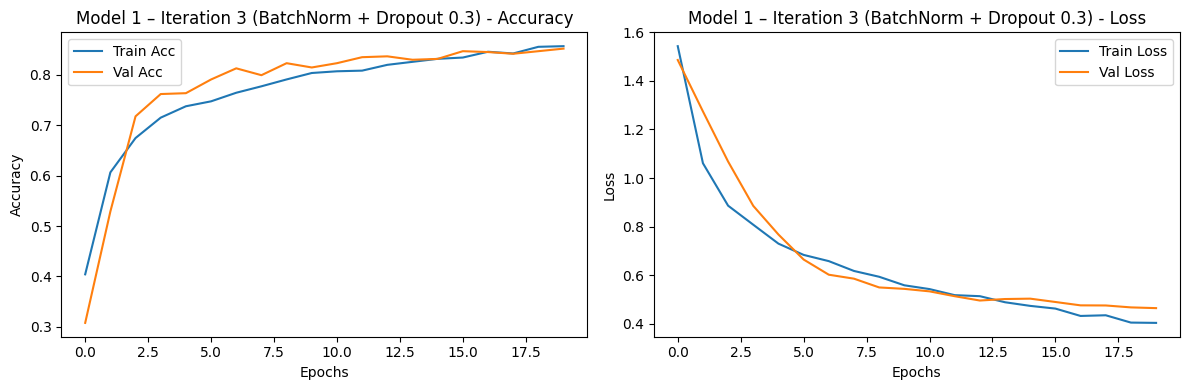

In [ ]:
plot_history(history_1_3, "Model 1 – Iteration 3 (BatchNorm + Dropout 0.3)")

In [ ]:
# Custom head: GlobalAveragePooling → Dense(256, relu) → BatchNormalization → Dropout(0.3) → Dense(5, softmax)
# Regularization: BatchNormalization and reduced Dropout(0.3)
# Optimizer: Adam, learning rate = 1e-4
# Batch size: 32
# Early stopping used (patience=3)
# Training Accuracy: 85.7%, Validation Accuracy: 85.2%
# Training Loss: 0.4029, Validation Loss: 0.4637
# Result: This configuration achieved the best overall balance.
  #Accuracy improved across both training and validation sets compared to previous iterations.
  #The learning curves show smooth convergence with minimal overfitting, and the model generalizes well.
  #BatchNormalization and reduced Dropout helped stabilize training and improve confidence.

## Model 1.4 - Changing optimizer to SGD with momentum

In [ ]:
# 1. Freeze VGG16 base layers
for layer in vgg_base.layers:
    layer.trainable = False

# 2. Add classification head (same as Iteration 3)
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(5, activation='softmax')(x)

# 3. Create model
model_1_4 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile with SGD optimizer
model_1_4.compile(
    optimizer=SGD(learning_rate=1e-2, momentum=0.9),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 6. Train
history_1_4 = model_1_4.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 24s 282ms/step - accuracy: 0.5715 - loss: 1.1325 - val_accuracy: 0.3997 - val_loss: 1.3989
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 35s 222ms/step - accuracy: 0.7763 - loss: 0.6245 - val_accuracy: 0.4269 - val_loss: 1.2911
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 17s 228ms/step - accuracy: 0.8010 - loss: 0.5442 - val_accuracy: 0.6514 - val_loss: 0.9884
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 16s 219ms/step - accuracy: 0.7936 - loss: 0.5866 - val_accuracy: 0.6820 - val_loss: 0.8806
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 240ms/step - accuracy: 0.8312 - loss: 0.4792 - val_accuracy: 0.6769 - val_loss: 0.8277
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 16s 210ms/step - accuracy: 0.8503 - loss: 0.4298 - val_accuracy: 0.7330 - val_loss: 0.7198
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 217ms/step - accuracy: 0.8370 - loss: 0.4456 - val_accuracy: 0.7551 - val_loss: 0.6767
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 222ms/step - accuracy: 0.8301 - loss: 0.4440 - val_accu

### Model 1.4 - Model results

In [ ]:
summarize_model_results(history_1_4, "Model 1 – Iteration 4 (SGD Optimizer)")


📌 Model 1 – Iteration 4 (SGD Optimizer)

| Metric              |   Value |
|---------------------|---------|
| Training Accuracy   |  0.8599 |
| Validation Accuracy |  0.818  |
| Training Loss       |  0.3924 |
| Validation Loss     |  0.5558 |


### Model 1.4 - Learning curves

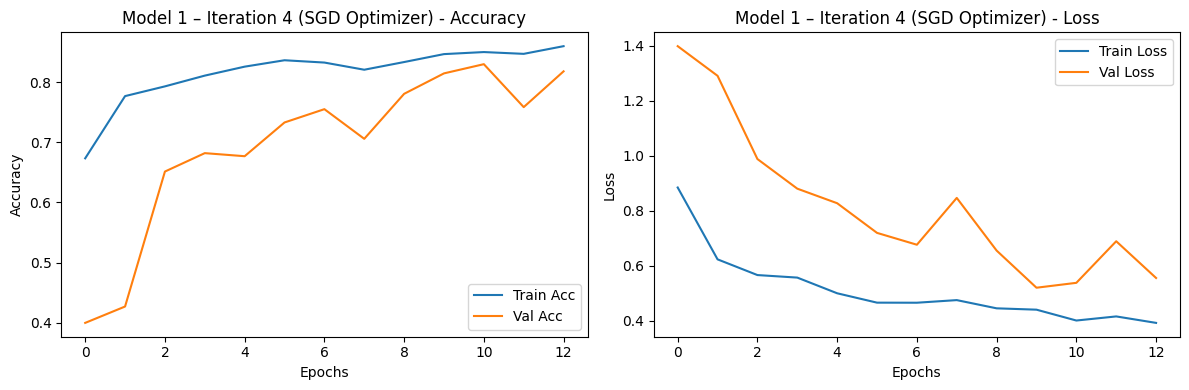

In [ ]:
plot_history(history_1_4, "Model 1 – Iteration 4 (SGD Optimizer)")

In [ ]:
# Custom head: GlobalAveragePooling → Dense(256, relu) → BatchNormalization → Dropout(0.3) → Dense(5, softmax)
# Regularization: BatchNormalization and Dropout(0.3)
# Optimizer: SGD (learning rate = 1e-2, momentum = 0.9)
# Batch size: 32
# Early stopping used (patience=3)
# Training Accuracy: 85.99%, Validation Accuracy: 81.8%
# Training Loss: 0.3924, Validation Loss: 0.5558
#Result: SGD achieved the highest training accuracy so far, with competitive validation accuracy.
    #However, learning curves show instability in validation performance, indicating that the optimizer may benefit from learning rate scheduling or additional tuning.
    #Overall, SGD showed strong potential but slightly weaker generalization compared to Adam + BatchNorm in Iteration 3.

## Model 1.5 - Adding extra Dense layer to Model 1.3

In [ ]:
# 1. Freeze VGG16 base layers
for layer in vgg_base.layers:
    layer.trainable = False

# 2. Add deeper classification head
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
x = Dense(128, activation='relu')(x)     # NEW: additional Dense layer
x = Dropout(0.3)(x)
output = Dense(5, activation='softmax')(x)

# 3. Create model
model_1_5 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile with Adam
model_1_5.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 6. Train
history_1_5 = model_1_5.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 26s 290ms/step - accuracy: 0.2690 - loss: 1.8826 - val_accuracy: 0.4031 - val_loss: 1.4789
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 34s 219ms/step - accuracy: 0.5226 - loss: 1.2391 - val_accuracy: 0.6667 - val_loss: 1.3107
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 246ms/step - accuracy: 0.6123 - loss: 0.9981 - val_accuracy: 0.7262 - val_loss: 1.1135
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 216ms/step - accuracy: 0.6447 - loss: 0.9167 - val_accuracy: 0.7483 - val_loss: 0.9327
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 241ms/step - accuracy: 0.6838 - loss: 0.8225 - val_accuracy: 0.7687 - val_loss: 0.7895
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 218ms/step - accuracy: 0.6934 - loss: 0.7903 - val_accuracy: 0.7823 - val_loss: 0.6921
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 22s 244ms/step - accuracy: 0.7057 - loss: 0.7691 - val_accuracy: 0.7993 - val_loss: 0.6356
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 243ms/step - accuracy: 0.7572 - loss: 0.6729 - val_accu

### Model 1.5 - Model results

In [ ]:
summarize_model_results(history_1_5, "Model 1 – Iteration 5 (Deeper Head + Adam)")


📌 Model 1 – Iteration 5 (Deeper Head + Adam)

| Metric              |   Value |
|---------------------|---------|
| Training Accuracy   |  0.8279 |
| Validation Accuracy |  0.8418 |
| Training Loss       |  0.4798 |
| Validation Loss     |  0.4715 |


### Model 1.5 - Learning curves

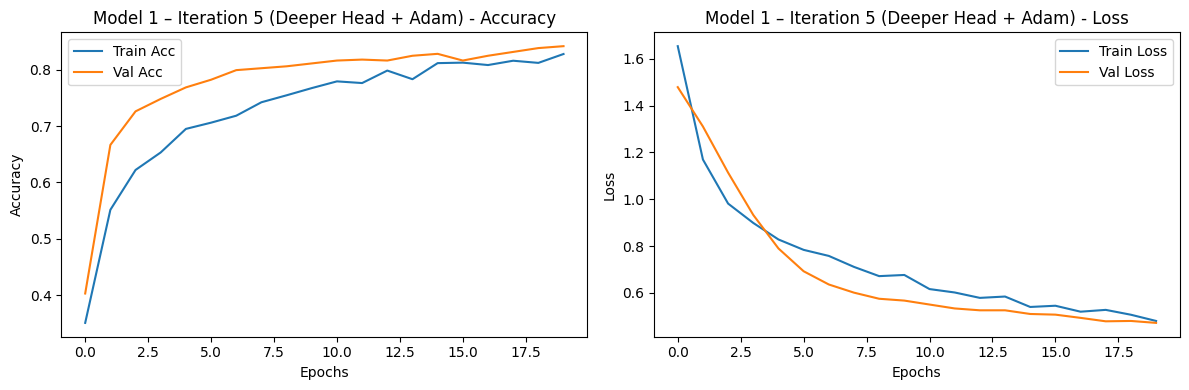

In [ ]:
plot_history(history_1_5, "Model 1 – Iteration 5 (Deeper Head + Adam)")

In [ ]:
# Custom head: GlobalAveragePooling → Dense(256, relu) → BatchNormalization → Dropout(0.3) → Dense(128, relu) → Dropout(0.3) → Dense(5, softmax)
# Regularization: Two Dropout layers (rate 0.3) and BatchNormalization
# Optimizer: Adam, learning rate = 1e-4
# Batch size: 32
# Early stopping used (patience=3)
# Training Accuracy: 82.8%, Validation Accuracy: 84.2%
# Training Loss: 0.4798, Validation Loss: 0.4715
#Result: The deeper architecture achieved one of the best validation accuracies across all iterations.
  #Training and validation loss curves converged smoothly, and the gap between training and validation accuracy remained tight.
  #The second dense layer increased model capacity without introducing overfitting.

## Model 1 - Analysing sub-models

In [ ]:
# The table below compares all sub-models trained under Model 1.
# Each version introduces architectural or training changes (e.g., Dropout, BatchNormalization, optimizer type, or added depth).
# Based on validation accuracy and training dynamics, Iteration 1.3 emerged as the strongest generalizing model.
# Iteration 1.5 also performed competitively with a deeper architecture.

In [ ]:
from tabulate import tabulate

summary_data = [
    ["1.1", "Dense(256)",                      0.8015, 0.8214, 0.5976, 0.5987, "Baseline"],
    ["1.2", "Dense(256) + Dropout(0.5)",       0.7491, 0.7789, 0.7270, 0.6727, "Underfit slightly"],
    ["1.3", "Dense(256) + BN + Dropout(0.3)",  0.8569, 0.8520, 0.4029, 0.4637, "Best generalization"],
    ["1.4", "Same as 1.3 + SGD",               0.8599, 0.8180, 0.3924, 0.5558, "Less stable"],
    ["1.5", "Deeper head + Adam",              0.8279, 0.8418, 0.4798, 0.4715, "Good depth balance"]
]

headers = ["Iteration", "Architecture", "Train Acc", "Val Acc", "Train Loss", "Val Loss", "Notes"]

print(tabulate(summary_data, headers=headers, tablefmt="github"))


|   Iteration | Architecture                   |   Train Acc |   Val Acc |   Train Loss |   Val Loss | Notes               |
|-------------|--------------------------------|-------------|-----------|--------------|------------|---------------------|
|         1.1 | Dense(256)                     |      0.8015 |    0.8214 |       0.5976 |     0.5987 | Baseline            |
|         1.2 | Dense(256) + Dropout(0.5)      |      0.7491 |    0.7789 |       0.727  |     0.6727 | Underfit slightly   |
|         1.3 | Dense(256) + BN + Dropout(0.3) |      0.8569 |    0.852  |       0.4029 |     0.4637 | Best generalization |
|         1.4 | Same as 1.3 + SGD              |      0.8599 |    0.818  |       0.3924 |     0.5558 | Less stable         |
|         1.5 | Deeper head + Adam             |      0.8279 |    0.8418 |       0.4798 |     0.4715 | Good depth balance  |


In [ ]:
# Conclusion: Based on the table, Model 1 – Iteration 3 shows the highest validation accuracy and lowest loss with minimal overfitting.
# This version will be evaluated on the test set.

## Model 1 - Evaluate model 1 (Iteration 3) performance on test set

In [ ]:
test_loss, test_acc = model_1_3.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Loss: {test_loss:.4f}")

Test Accuracy: 0.8597
Test Loss: 0.4226


### Model 1 - Confusion matrix

23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 201ms/step


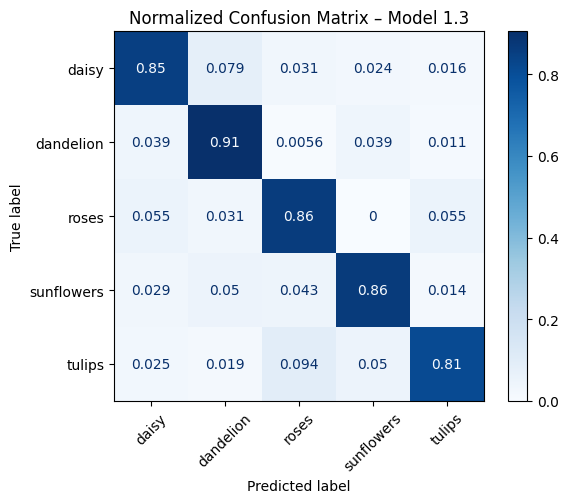

In [ ]:
# Predict class probabilities
y_pred_probs = model_1_3.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# Create normalized confusion matrix
cm = confusion_matrix(y_test, y_pred, normalize='true')

# Display matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Normalized Confusion Matrix – Model 1.3")
plt.show()


In [ ]:
# The model shows strong and balanced performance across all 5 flower classes.
# Dandelions are the easiest to classify, with a 91% true positive rate and minimal confusion.
# Tulips are the most challenging class, with 9.4% misclassified as roses and some overlap with sunflowers.
# All off-diagonal confusion rates are low (mostly below 10%), indicating good class separation.
# The confusion matrix confirms that Model 1.3 generalizes well

# Model 2 - Unfreeze the last block of VGG16 (block5) and use Model 1.3 as basis

In [ ]:
# 1. Unfreeze only block5 layers in VGG16
set_trainable = False
for layer in vgg_base.layers:
    if "block5" in layer.name:
        set_trainable = True
    layer.trainable = set_trainable

# 2. Rebuild custom head (same as Model 1.3)
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(5, activation='softmax')(x)

# 3. Define Model 2
model_2 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile
model_2.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 6. Train
history_2 = model_2.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 29s 319ms/step - accuracy: 0.7788 - loss: 0.6104 - val_accuracy: 0.7908 - val_loss: 0.7683
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 33s 256ms/step - accuracy: 0.9719 - loss: 0.0970 - val_accuracy: 0.8571 - val_loss: 0.5525
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 256ms/step - accuracy: 0.9851 - loss: 0.0601 - val_accuracy: 0.8656 - val_loss: 0.4436
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 20s 249ms/step - accuracy: 0.9921 - loss: 0.0370 - val_accuracy: 0.8078 - val_loss: 0.7328
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 18s 248ms/step - accuracy: 0.9901 - loss: 0.0471 - val_accuracy: 0.8759 - val_loss: 0.3679
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 23s 276ms/step - accuracy: 0.9997 - loss: 0.0102 - val_accuracy: 0.8895 - val_loss: 0.3805
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 19s 253ms/step - accuracy: 0.9974 - loss: 0.0110 - val_accuracy: 0.8827 - val_loss: 0.4337
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 21s 278ms/step - accuracy: 0.9879 - loss: 0.0480 - val_accu

## Model 2 - Model results

In [ ]:
summarize_model_results(history_2, "Model 2 – Unfreeze Block5")


📌 Model 2 – Unfreeze Block5

| Metric              |   Value |
|---------------------|---------|
| Training Accuracy   |  0.9825 |
| Validation Accuracy |  0.8197 |
| Training Loss       |  0.0621 |
| Validation Loss     |  0.7033 |


## Model 2 - Learning curves

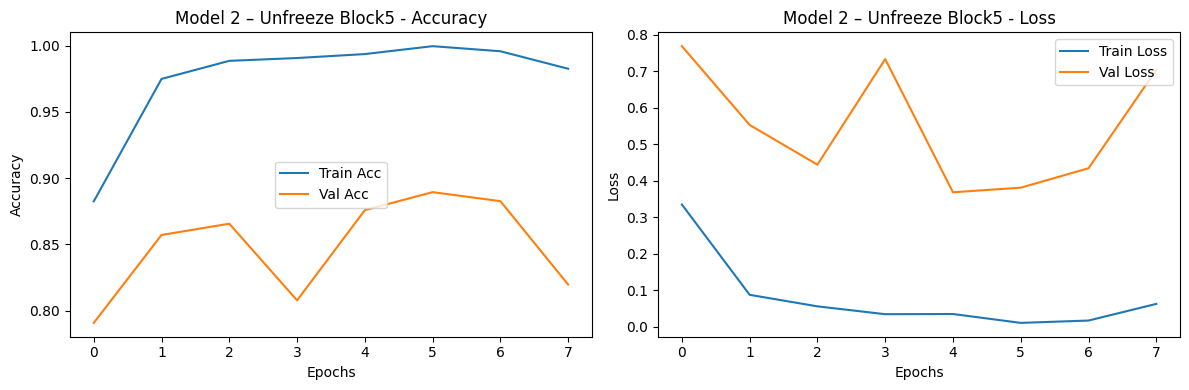

In [ ]:
plot_history(history_2, "Model 2 – Unfreeze Block5")

In [ ]:
# Custom head: GlobalAveragePooling → Dense(256, relu) → BatchNormalization → Dropout(0.3) → Dense(5, softmax)
# Base model: VGG16 with block5 layers unfrozen for fine-tuning
# Optimizer: Adam, learning rate = 1e-4
# Batch size: 32
# Early stopping used (patience=3)
# Training Accuracy: 98.25%, Validation Accuracy: 81.97%
# Training Loss: 0.0621, Validation Loss: 0.7033
#Result: The model learned rapidly after unfreezing block5, achieving near-perfect training accuracy.
  #However, the gap between training and validation loss widened, suggesting signs of overfitting.
  #The validation loss curve fluctuates significantly after epoch 3, and early stopping correctly halted training at epoch 8.
  #While fine-tuning improved training performance, it did not improve generalization compared to the fully frozen model (Model 1.3).

## Model 2 - Evaluate performance on test set

In [ ]:
test_loss_2, test_acc_2 = model_2.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (Model 2): {test_acc_2:.4f}")
print(f"Test Loss (Model 2):     {test_loss_2:.4f}")

Test Accuracy (Model 2): 0.8937
Test Loss (Model 2):     0.3395


## Model 2 - Confusion matrix

23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 198ms/step


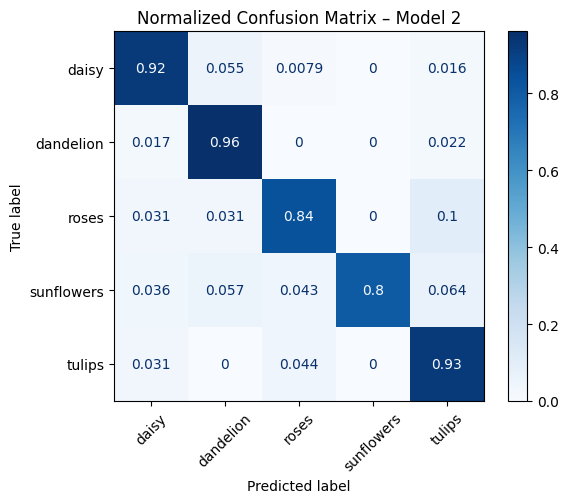

In [ ]:
# Predict test classes
y_pred_probs_2 = model_2.predict(X_test)
y_pred_2 = np.argmax(y_pred_probs_2, axis=1)

# Confusion matrix (normalized)
cm_2 = confusion_matrix(y_test, y_pred_2, normalize='true')

disp_2 = ConfusionMatrixDisplay(confusion_matrix=cm_2, display_labels=class_names)
disp_2.plot(cmap='Blues', xticks_rotation=45)
plt.title("Normalized Confusion Matrix – Model 2")
plt.show()

In [ ]:
# Test Accuracy: 89.4%, Test Loss: 0.3395
# Unfreezing block5 boosted training performance but introduced overfitting
# Significant train/validation gap observed in the learning curves — early stopping helped contain it
# Dandelions (96%) and Tulips (93%) were classified most accurately
# Sunflowers (80%) had the lowest accuracy, with confusion primarily against dandelions and tulips
# Roses were misclassified as tulips in 10% of cases
# Despite signs of overfitting, the model generalizes well on the test set and demonstrates strong class separation

# Model 3 - Unfreeze all layers of VGG16

In [ ]:
# 1. Unfreeze all layers of VGG16
for layer in vgg_base.layers:
    layer.trainable = True

# 2. Rebuild the custom classification head
x = vgg_base.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.3)(x)
output = Dense(5, activation='softmax')(x)

# 3. Build model
model_3 = Model(inputs=vgg_base.input, outputs=output)

# 4. Compile
model_3.compile(
    optimizer=Adam(learning_rate=1e-4),  # Unchanged as requested
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

# 6. Train
history_3 = model_3.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 101s 812ms/step - accuracy: 0.6447 - loss: 0.9612 - val_accuracy: 0.8333 - val_loss: 0.5363
Epoch 2/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 85s 538ms/step - accuracy: 0.8840 - loss: 0.3149 - val_accuracy: 0.8537 - val_loss: 0.4072
Epoch 3/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 42s 550ms/step - accuracy: 0.9113 - loss: 0.2593 - val_accuracy: 0.8622 - val_loss: 0.3771
Epoch 4/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 39s 525ms/step - accuracy: 0.9480 - loss: 0.1505 - val_accuracy: 0.8605 - val_loss: 0.4273
Epoch 5/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 43s 551ms/step - accuracy: 0.9673 - loss: 0.0933 - val_accuracy: 0.8707 - val_loss: 0.4604
Epoch 6/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 39s 527ms/step - accuracy: 0.9549 - loss: 0.1305 - val_accuracy: 0.8929 - val_loss: 0.3270
Epoch 7/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 43s 552ms/step - accuracy: 0.9342 - loss: 0.1893 - val_accuracy: 0.8912 - val_loss: 0.3255
Epoch 8/20
74/74 ━━━━━━━━━━━━━━━━━━━━ 41s 552ms/step - accuracy: 0.9801 - loss: 0.0610 - val_acc

## Model 3 - Model results

In [ ]:
summarize_model_results(history_3, "Model 3 – Unfreeze All Layers")


📌 Model 3 – Unfreeze All Layers

| Metric              |   Value |
|---------------------|---------|
| Training Accuracy   |  0.9945 |
| Validation Accuracy |  0.869  |
| Training Loss       |  0.0202 |
| Validation Loss     |  0.4431 |


## Model 3 - Learning curves

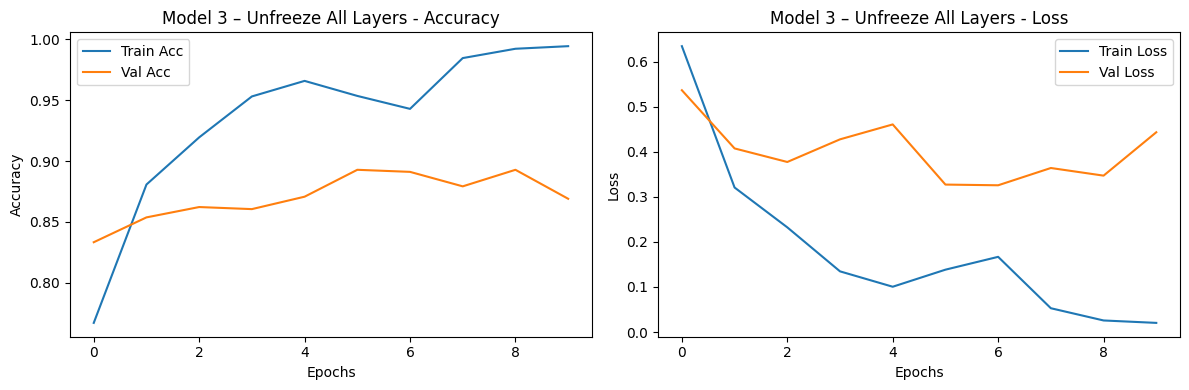

In [ ]:
plot_history(history_3, "Model 3 – Unfreeze All Layers")

In [ ]:
# Model 3 achieved Training Accuracy of 99.45% and Validation Accuracy of 86.9%
# Final Training Loss was 0.0202, and Validation Loss was 0.4431
# The learning curves show a very steep drop in training loss, with accuracy saturating near 100%
# Validation accuracy peaked around epoch 6, then fluctuated slightly, while validation loss remained relatively flat
# The large gap between training and validation metrics indicates the model is likely overfitting
# Full fine-tuning provided higher validation accuracy than previous models, but with less stable generalization

## Model 3 - Evaluate performance on test set

In [ ]:
test_loss_3, test_acc_3 = model_3.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy (Model 3): {test_acc_3:.4f}")
print(f"Test Loss (Model 3):     {test_loss_3:.4f}")

Test Accuracy (Model 3): 0.8978
Test Loss (Model 3):     0.2763


Model 3 - Confusion matrix

23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 203ms/step


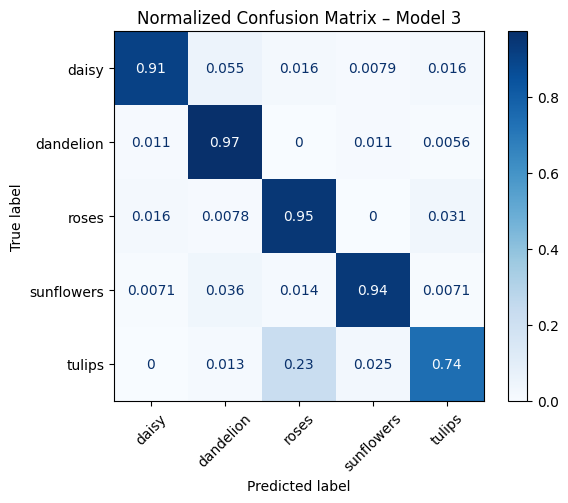

In [ ]:
# Predict probabilities and get class predictions
y_pred_probs_3 = model_3.predict(X_test)
y_pred_3 = np.argmax(y_pred_probs_3, axis=1)

# Generate normalized confusion matrix
cm_3 = confusion_matrix(y_test, y_pred_3, normalize='true')

# Display the matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm_3, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45)
plt.title("Normalized Confusion Matrix – Model 3")
plt.show()

In [ ]:
# Model 3 achieved the highest test performance, but at the cost of heavy overfitting, as reflected by the large train/validation gap
# Validation loss fluctuated, but final test loss remained low — indicating that early stopping captured a good generalization point
# Tulip misclassification remains the model’s main weakness, suggesting that certain flower types may need targeted refinement
# Overall, Model 3 shows exceptional capacity and potential, but benefits from strong regularization or conservative fine-tuning when all layers are trainable

# Model Comparison

In [ ]:
# Final model comparison data
final_models = [
    ["Model 1.3", "Frozen (all)",        "85.69%", "85.20%", "85.97%", "Minimal",     "Best generalization, stable training"],
    ["Model 2",   "Unfreeze block5",     "98.25%", "81.97%", "89.37%", "Significant", "Improved accuracy, some overfitting"],
    ["Model 3",   "Unfreeze all layers", "99.45%", "86.90%", "89.78%", "Large",       "Highest test accuracy, heavy overfitting"]
]

headers = ["Model", "VGG16 Layers", "Train Acc", "Val Acc", "Test Acc", "Train–Val Gap", "Notes"]

# Print the table
print(tabulate(final_models, headers=headers, tablefmt="github"))

| Model     | VGG16 Layers        | Train Acc   | Val Acc   | Test Acc   | Train–Val Gap   | Notes                                    |
|-----------|---------------------|-------------|-----------|------------|-----------------|------------------------------------------|
| Model 1.3 | Frozen (all)        | 85.69%      | 85.20%    | 85.97%     | Minimal         | Best generalization, stable training     |
| Model 2   | Unfreeze block5     | 98.25%      | 81.97%    | 89.37%     | Significant     | Improved accuracy, some overfitting      |
| Model 3   | Unfreeze all layers | 99.45%      | 86.90%    | 89.78%     | Large           | Highest test accuracy, heavy overfitting |


In [ ]:
# Model 1 (All Layers Frozen)
  # Test Accuracy: 85.97%
  # Achieved strong generalization with minimal overfitting.
  # Only trained the custom classification head, preserving pretrained features from ImageNet.
    # This made it stable and sample-efficient, especially with regularization (BatchNorm + Dropout).

In [ ]:
# Model 2 (Unfreeze block5)
  # Test Accuracy: 89.37%
  # Fine-tuning the last convolutional block improved test performance by adapting high-level filters to flower-specific features.
  # Introduced some overfitting, as shown by the validation accuracy drop and widening gap between train/val.

In [ ]:
# Model 3 (Unfreeze All Layers)
  # Test Accuracy: 89.78% (highest)
  # Fully fine-tuned all VGG16 layers, enabling the model to learn domain-specific features throughout the network.
  # Exhibited heavy overfitting — training accuracy was nearly perfect, but validation loss fluctuated.
    # Tulips were notably misclassified, suggesting reduced robustness.

In [ ]:
# Final Conclusion
  # Model 3 achieved the highest test accuracy, but exhibited the most overfitting
  # Model 2 provided a good compromise between learning capacity and generalization
  # Model 1.3 offered the cleanest generalization and is the most stable and efficient